In [1]:
import pandas as pd






In [2]:
#This is the code I used to import SQL data into python

patients_df = pd.read_csv('data/Patients-Table.csv')
encounters_df = pd.read_csv('data/Encounters-Table.csv')
conditions_df = pd.read_csv('data/Conditions-Table-1.csv')
immunizations_df = pd.read_csv('data/immunizations-Table.csv')



In [3]:
#I Reviewed, rows, Columns and data types but utilizing this code 
patients_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   30 non-null     object 
 1   birthdate            30 non-null     object 
 2   deathdate            0 non-null      float64
 3   ssn                  0 non-null      float64
 4   drivers              0 non-null      float64
 5   passport             0 non-null      float64
 6   prefix               0 non-null      float64
 7   first                30 non-null     object 
 8   last                 30 non-null     object 
 9   suffix               0 non-null      float64
 10  maiden               0 non-null      float64
 11  marital              0 non-null      float64
 12  race                 0 non-null      float64
 13  ethnicity            0 non-null      float64
 14  gender               30 non-null     object 
 15  birthplace           0 non-null      float

In [4]:
#Checked for missing values across all datasets
print("Patients Missing Values:\n", patients_df.isnull().sum(), "\n")
print("Encounters Missing Values:\n", encounters_df.isnull().sum(), "\n")
print("Conditions Missing Values:\n", conditions_df.isnull().sum(), "\n")
print("Immunizations Missing Values:\n", immunizations_df.isnull().sum())

Patients Missing Values:
 id                      0
birthdate               0
deathdate              30
ssn                    30
drivers                30
passport               30
prefix                 30
first                   0
last                    0
suffix                 30
maiden                 30
marital                30
race                   30
ethnicity              30
gender                  0
birthplace             30
address                30
city                    0
state                   0
county                 30
fips                   30
zip                     0
lat                    30
lon                    30
healthcare_expenses    30
healthcare_coverage    30
income                 30
mrn                    30
dtype: int64 

Encounters Missing Values:
 id                      0
start                   0
stop                    0
patient                 0
organization           33
provider               33
payer                  33
encounterclass       

In [5]:
# Checked for duplicate rows across all datasets at once
dfs = {
    'Patients': patients_df,
    'Encounters': encounters_df,
    'Conditions': conditions_df,
    'Immunizations': immunizations_df
}

print("--- Duplicate Row Counts ---")
for name, df in dfs.items():
    print(f"{name}: {df.duplicated().sum()} duplicate rows")

--- Duplicate Row Counts ---
Patients: 0 duplicate rows
Encounters: 0 duplicate rows
Conditions: 0 duplicate rows
Immunizations: 0 duplicate rows


### Reproduce at least two of your SQL findings

In [6]:
Question 1:How many unique patients are in the database?
unique_patient_count = patients_df['id'].nunique()
print("Total Unique Patients:", unique_patient_count)

Object `database` not found.
Total Unique Patients: 30


In [7]:
#  What are the most common diagnoses or health conditions
most_common_conditions = conditions_df['description'].value_counts().head(5)

print("Most Common Diagnoses/Conditions:")
print(most_common_conditions)

Most Common Diagnoses/Conditions:
description
Type 2 diabetes mellitus without complications    3
Essential (primary) hypertension                  3
Unspecified asthma, uncomplicated                 3
Acute myocardial infarction, unspecified          2
Heart failure, unspecified                        2
Name: count, dtype: int64


# I created 3 Charts using Seaborn

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns


# ## Most Common Diagnoses

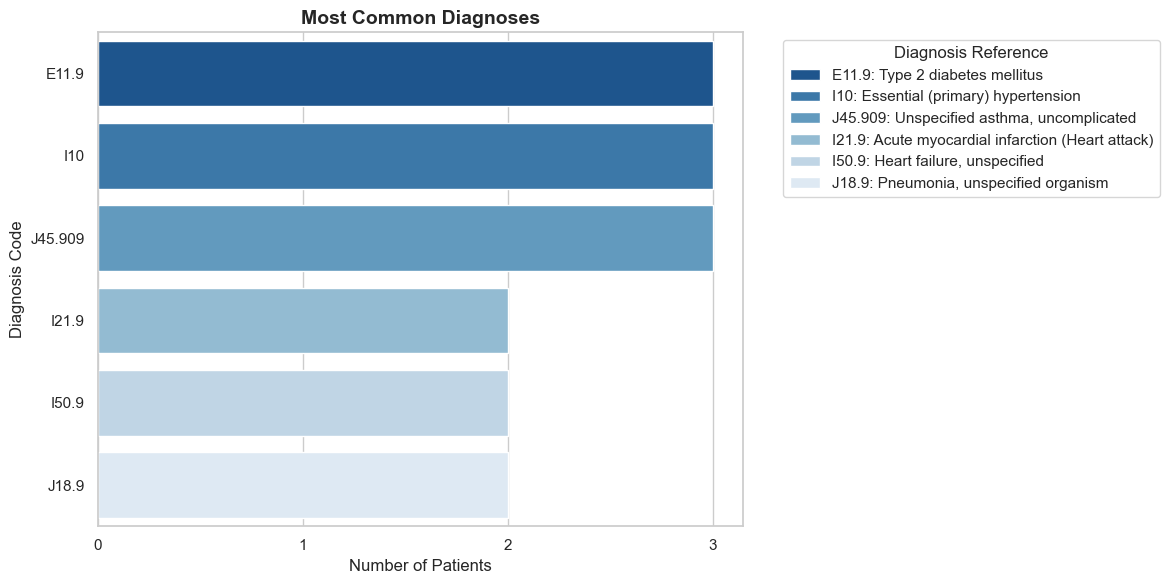

In [9]:

# Set chart style
sns.set_theme(style="whitegrid")

# 1. Filter diagnoses appearing more than once
counts = conditions_df['code'].value_counts()
common_counts = counts[counts > 1].reset_index()
common_counts.columns = ['diagnosis_code', 'number_of_patients']

# 2. Updated diagnosis dictionary including the missing codes
code_map = {
    'E11.9': 'Type 2 diabetes mellitus',
    'I10': 'Essential (primary) hypertension',
    'J45.909': 'Unspecified asthma, uncomplicated',
    'I21.9': 'Acute myocardial infarction (Heart attack)',
    'I50.9': 'Heart failure, unspecified',
    'J18.9': 'Pneumonia, unspecified organism',
    'J44.9': 'Chronic obstructive pulmonary disease (COPD)',
    'J06.9': 'Acute upper respiratory infection',
    'F41.1': 'Generalized anxiety disorder',
    'F32.9': 'Major depressive disorder',
    'M54.5': 'Low back pain',
    'K21.9': 'Gastro-esophageal reflux disease (GERD)',
    'Z00.00': 'General adult medical examination'
}

# 3. Create formatted legend label column
common_counts['legend_label'] = common_counts['diagnosis_code'].apply(
    lambda code: f"{code}: {code_map.get(str(code), 'Description Not Found')}"
)

# 4. Create plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=common_counts,
    x='number_of_patients',
    y='diagnosis_code',
    hue='legend_label',
    palette='Blues_r',
    dodge=False
)

# Force X-axis ticks to display only whole integers
max_count = common_counts['number_of_patients'].max()
plt.xticks(range(0, max_count + 1))

# Position legend neatly
sns.move_legend(
    ax, 
    loc="upper left", 
    bbox_to_anchor=(1.05, 1), 
    title="Diagnosis Reference"
)

# Set labels and title
plt.title('Most Common Diagnoses', fontsize=14, fontweight='bold')
plt.xlabel('Number of Patients', fontsize=12)
plt.ylabel('Diagnosis Code', fontsize=12)

plt.tight_layout()
plt.show()

# Encounters/visits by age group


In [10]:
# 1. Merge encounters with patients to get birthdate
# Adjust column names ('id', 'patient_id', 'birthdate') if needed
encounters_with_age = encounters_df.merge(
    patients_df[['id', 'birthdate']], 
    left_on='patient', 
    right_on='id'
)

# 2. Calculate patient age (assuming birthdate is datetime or convert it)
encounters_with_age['birthdate'] = pd.to_datetime(encounters_with_age['birthdate'])
# Calculate age in years relative to encounter date or current date
encounters_with_age['age'] = (pd.to_datetime('today') - encounters_with_age['birthdate']).dt.days // 365

# 3. Create Age Group Bins
bins = [-1, 18, 25, 35, 45, 55, 65, 120]
labels = ['< 18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']

encounters_with_age['age_group'] = pd.cut(
    encounters_with_age['age'], 
    bins=bins, 
    labels=labels
)

# 4. Count total encounters per age group
encounter_counts = encounters_with_age['age_group'].value_counts().reset_index()
encounter_counts.columns = ['age_group', 'number_of_encounters']

C:\Users\sol4r\AppData\Local\Temp\ipykernel_35028\177151953.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


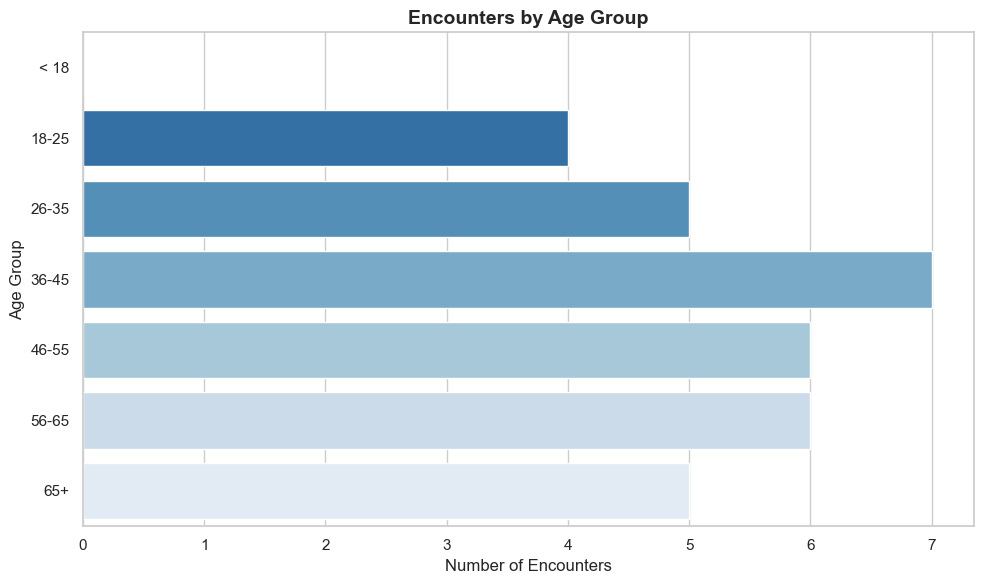

In [11]:
# Set chart style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=encounter_counts,
    x='number_of_encounters',
    y='age_group',
    palette='Blues_r'
)

# Force X-axis ticks to display only whole integers (no decimals)
max_count = encounter_counts['number_of_encounters'].max()
plt.xticks(range(0, max_count + 1))

# Set labels and capitalized title
plt.title('Encounters by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Number of Encounters', fontsize=12)
plt.ylabel('Age Group', fontsize=12)

plt.tight_layout()
plt.show()

# Conditions with the highest Utlization 

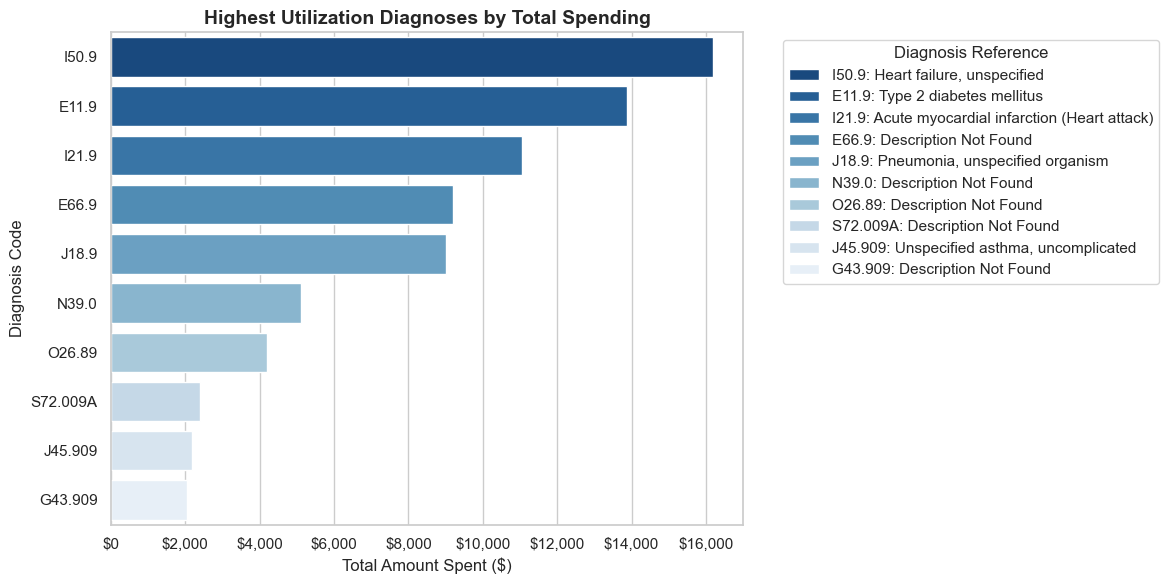

In [12]:
# Set chart style
sns.set_theme(style="whitegrid")

# 1. Merge conditions with encounters to get spending data
# (Adjust 'encounter' / 'id' if your primary key column names differ)
condition_spending = conditions_df.merge(
    encounters_df[['id', 'total_claim_cost']], 
    left_on='encounter', 
    right_on='id'
)

# 2. Aggregate total cost by diagnosis code and get the Top 10
top_cost_diagnoses = (
    condition_spending.groupby('code')['total_claim_cost']
    .sum()
    .reset_index()
    .sort_values(by='total_claim_cost', ascending=False)
    .head(10)
)
top_cost_diagnoses.columns = ['diagnosis_code', 'total_spending']

# 3. Manually define diagnosis codes and their clinical descriptions
code_map = {
    'E11.9': 'Type 2 diabetes mellitus',
    'I10': 'Essential (primary) hypertension',
    'J45.909': 'Unspecified asthma, uncomplicated',
    'I21.9': 'Acute myocardial infarction (Heart attack)',
    'I50.9': 'Heart failure, unspecified',
    'J18.9': 'Pneumonia, unspecified organism',
    'J44.9': 'Chronic obstructive pulmonary disease (COPD)',
    'J06.9': 'Acute upper respiratory infection',
    'F41.1': 'Generalized anxiety disorder',
    'F32.9': 'Major depressive disorder',
    'M54.5': 'Low back pain',
    'K21.9': 'Gastro-esophageal reflux disease (GERD)',
    'Z00.00': 'General adult medical examination'
}

# 4. Create formatted legend labels
top_cost_diagnoses['legend_label'] = top_cost_diagnoses['diagnosis_code'].apply(
    lambda code: f"{code}: {code_map.get(str(code), 'Description Not Found')}"
)

# 5. Create horizontal bar plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=top_cost_diagnoses,
    x='total_spending',
    y='diagnosis_code',
    hue='legend_label',
    palette='Blues_r',
    dodge=False
)

# 6. Format X-axis numbers as currency (e.g., $50,000)
ax.xaxis.set_major_formatter('${x:,.0f}')

# Position legend outside plot
sns.move_legend(
    ax, 
    loc="upper left", 
    bbox_to_anchor=(1.05, 1), 
    title="Diagnosis Reference"
)

# Set labels and title
plt.title('Highest Utilization Diagnoses by Total Spending', fontsize=14, fontweight='bold')
plt.xlabel('Total Amount Spent ($)', fontsize=12)
plt.ylabel('Diagnosis Code', fontsize=12)

plt.tight_layout()
plt.show()

# Key Finding #1
* Data Analysis Insight: While heart failure (I50.9) ranks among the top diagnoses in overall volume, cross-referencing encounter demographics reveals significant utilization within the 36–45 age bracket—an unexpectedly young cohort for high-volume heart failure management.


# Key Finiding 2
* The highest-utilization diagnoses—specifically Obesity (`E66.9`), Type 2 Diabetes (`E11.9`), Heart Attack (`I21.9`), and Heart Failure (`I50.9`)—highlight a strong clinical correlation between metabolic dysfunction and severe cardiovascular events. Given that the 36–45 age cohort represents the highest encounter volume, this pattern underscores the critical need for early preventative care, nutritional counseling, and lifestyle interventions aimed at managing metabolic risk factors before they progress to acute cardiac conditions.

# Key Finiding 3
* Cardiovascular System Drives Highest Overall Utilization**
   When aggregating diagnosis codes by clinical body system, the cardiovascular system represents the single most treated organ system in the patient population. High-volume codes such as Essential Hypertension (`I10`), Heart Failure (`I50.9`), and Acute Myocardial Infarction (`I21.9`) account for a major portion of total care visits and resource utilization.
